In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(
    r"C:\Users\mm428\Downloads\flipkart_product.csv\flipkart_product.csv",
   encoding='latin1'
)


In [3]:
pd.set_option('display.max_colwidth',None)

In [4]:
df.sample(10)

,ProductName,Price,Rate,Review,Summary
178202,AGARO Regal Hand-held Vacuum CleanerÂ Â (Black),"â¹1,599",4,Wonderful,"Good, powerful vacuum, handy, easy to clean, just heating problem when we use for long time.Overall worth to buy."
72833,LICAN 301 Steel Coat Pack of 12 Hangers For CoatÂ Â (Steel),â¹156,5,Fabulous!,Very good product and received same item as they shown in picture
85311,"Clastik Solid Wood Study TableÂ Â (Finish Color - Multi Color, Pre-assembled)",â¹298,1,Worthless,Very bad
98568,Aero Seeds 40 Varieties of Flower Combo Pack SeedÂ Â (2050 per packet),â¹194,5,Fabulous!,"Awesome product blindfolded you can trust I have sown calendula, crystantamum. african marigold, dahila and sunflower tall.All seeds are germinated under 3days.Out of 40 seeds 39 are good, Sunflower miniature is not good it's ok one of the best products, you can go for this."
176972,Catvision CSR-401HP WIFI Media Streaming Device?ÿ?ÿ(Black),"??1,550",5,Highly recommended,Good product
5557,"Cosito 144 TC Cotton Double Floral Flat BedsheetÂ Â (Pack of 1, Red, White)",â¹339,5,Brilliant,Good quality and 100%cotton
49505,MANGALAM Camphor Tablet 100g Jar - Pack of 1,â¹195,5,Wonderful,Good for Pooja long time Brun
85061,"DEMYA KINF OF STEEL Solid wood Desk ChairÂ Â (Finish Color - Multicolor, Pre-assembled)",â¹606,5,Wonderful,Super product
5270,"aniket 180 TC Polycotton Double Printed Flat BedsheetÂ Â (Pack of 1, Multicolor)",â¹228,1,Terrible product,Very poor quality. Money is wasted 20 days after that.
91930,"MILTON Thermosteel Flip Lid 500 ml FlaskÂ Â (Pack of 1, Silver, Steel)",â¹648,5,Super!,Good quality product.


# Step 1 — Problem Understanding

# What is Sentiment Analysis?

### Sentiment Analysis means finding the feeling or opinion in text.

### We check whether a customer review is:

Positive → Happy review 😊
Neutral → Normal/average review 😐
Negative → Bad review 😞

# Business Question We Are Solving

## Which products are getting bad reviews, and why?

### This helps the company:

✅ Find products with many bad reviews
✅ Understand customer complaints (quality, delivery, price)
✅ Improve products and categories with problems

# step 2 :- data Understanding

In [5]:
df.shape

(189874, 5)

In [6]:
df.columns.tolist()

['ProductName', 'Price', 'Rate', 'Review', 'Summary']

In [7]:
df.dtypes

ProductName    object
Price          object
Rate           object
Review         object
Summary        object
dtype: object

In [8]:
# basic stats

In [9]:
print("                         numeric summary              ")
df.describe()

                         numeric summary              


,ProductName,Price,Rate,Review,Summary
count,189874,189873,189873,189870,189860
unique,812,561,9,1264,98343
top,"MILTON Thermosteel Flip Lid 500 ml FlaskÂ Â (Pack of 1, Silver, Steel)","â¹1,299",5,Nan,Good
freq,9278,10005,108694,20862,14175


In [10]:
# null valuese check 

In [11]:
df.isnull().sum()

ProductName     0
Price           1
Rate            1
Review          4
Summary        14
dtype: int64

In [12]:
round((df.isnull().sum()/df.shape[0])*100,4)

ProductName    0.0000
Price          0.0005
Rate           0.0005
Review         0.0021
Summary        0.0074
dtype: float64

In [13]:
# duplicates check 

In [14]:
df.duplicated().sum()

24861

In [15]:
# unique value check

In [16]:
# unique products 
df['ProductName'].nunique()

812

In [17]:
# unique rating 
df['Rate'].unique()

array(['5', '3', '1', '4', '2',
       'Pigeon Favourite Electric Kettle?ÿ?ÿ(1.5 L, Silver, Black)',
       'Bajaj DX 2 L/W Dry Iron',
       'Nova Plus Amaze NI 10 1100 W Dry Iron?ÿ?ÿ(Grey & Turquoise)', 's',
       nan], dtype=object)

In [18]:
df['Rate'].value_counts()

Rate
5                                                              108694
4                                                               39653
1                                                               19607
3                                                               15681
2                                                                6234
Pigeon Favourite Electric Kettle?ÿ?ÿ(1.5 L, Silver, Black)          1
Bajaj DX 2 L/W Dry Iron                                             1
Nova Plus Amaze NI 10 1100 W Dry Iron?ÿ?ÿ(Grey & Turquoise)         1
s                                                                   1
Name: count, dtype: int64

# step 3 :- Data Cleaning

In [19]:
# drop duplicates
df = (df
      .drop_duplicates()
     .reset_index(drop=True))


In [20]:
df.shape

(165013, 5)

In [21]:
# fix rate column
# See all non-numeric values in Rate
invalid_rates = df[~df['Rate'].astype(str).str.match(r'^\d+$')]
print("Invalid Rate rows:", len(invalid_rates))
print(invalid_rates['Rate'].value_counts())

Invalid Rate rows: 5
Rate
Pigeon Favourite Electric Kettle?ÿ?ÿ(1.5 L, Silver, Black)     1
Bajaj DX 2 L/W Dry Iron                                        1
Nova Plus Amaze NI 10 1100 W Dry Iron?ÿ?ÿ(Grey & Turquoise)    1
s                                                              1
Name: count, dtype: int64


In [22]:
# Keep only rows where Rate is 1-5
valid_ratings = ['1', '2', '3', '4', '5']
df = df[df['Rate'].isin(valid_ratings)]
df.reset_index(drop=True, inplace=True)

# Convert to integer
df['Rate'] = df['Rate'].astype(int)

print("After fixing Rate:", df.shape)
print("Rate unique values:", df['Rate'].unique())

After fixing Rate: (165008, 5)
Rate unique values: [5 3 1 4 2]


In [23]:
df['Rate'].value_counts()

Rate
5    93058
4    33207
1    18782
3    13946
2     6015
Name: count, dtype: int64

In [24]:
# fix price column 
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace(r'[^\d.]', '', regex=True)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

print("Price nulls after cleaning:", df['Price'].isnull().sum())
print(df['Price'].describe())

Price nulls after cleaning: 0
count    165008.000000
mean       4603.526665
std       10428.338051
min          59.000000
25%         339.000000
50%         840.000000
75%        3569.000000
max       86990.000000
Name: Price, dtype: float64


In [25]:
# handling null values 
# Replace string "Nan" with actual NaN
df['Review'] = df['Review'].replace('Nan', np.nan)

In [26]:
# Drop rows where Summary is null (primary text column)
df.dropna(subset=['Summary'], inplace=True)
df.reset_index(drop=True, inplace=True)

In [27]:
# Fill missing Review with empty string
df['Review'] = df['Review'].fillna('')

In [28]:
print("Nulls after cleaning:\n", df.isnull().sum())
print("\nShape:", df.shape)

Nulls after cleaning:
 ProductName    0
Price          0
Rate           0
Review         0
Summary        0
dtype: int64

Shape: (165003, 5)


In [29]:
df['text'] = df['Summary'].fillna('') + ' ' + df['Review'].fillna('')
df['text'] = df['text'].str.strip()

print("Sample text column:")
print(df['text'].head())

Sample text column:
0    Great cooler.. excellent air flow and for this price. It's so amazing and unbelievable.Just love it ?? Super!
1                                                                       Best budget 2 fit cooler. Nice cooling Awesome
2                                                              The quality is good but the power of air is decent Fair
3                                                                   Very bad product it's a only a fan Useless product
4                                                                                                   Ok ok product Fair
Name: text, dtype: object


In [30]:
# explination 
# The model now sees both pieces of information together — better prediction

In [31]:
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

print("Text length stats:")


# Remove reviews with less than 2 words or more than 200 words
before = len(df)
df = df[(df['text_length'] >= 2) & (df['text_length'] <= 200)]
df.reset_index(drop=True, inplace=True)

print(f"\nRemoved {before - len(df)} extreme length rows")
print("Final shape:", df.shape)

Text length stats:

Removed 1926 extreme length rows
Final shape: (163077, 7)


In [32]:
import re

def basic_text_clean(text):
    # Remove non-ASCII characters (emojis, encoding garbage)
    text = text.encode('ascii', 'ignore').decode('ascii')
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text'] = df['text'].apply(basic_text_clean)

# Recheck length after removing garbage
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

# Drop if text becomes too short after cleaning
df = df[df['text_length'] >= 2]
df.reset_index(drop=True, inplace=True)

print("Shape after emoji removal:", df.shape)
print(df['text'].head(10))

Shape after emoji removal: (162975, 7)
0    Great cooler.. excellent air flow and for this price. It's so amazing and unbelievable.Just love it ?? Super!
1                                                                   Best budget 2 fit cooler. Nice cooling Awesome
2                                                          The quality is good but the power of air is decent Fair
3                                                               Very bad product it's a only a fan Useless product
4                                                                                               Ok ok product Fair
5                            The cooler is really fantastic and provides good air flow. Highly recommended Awesome
6                                                                             Very good product Highly recommended
7                                                                                                   Very nice Nice
8                                        

In [33]:
# explination 
# Remove rows that are too short to be useful or too long to be clean

In [34]:
def label_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentiment'] = df['Rate'].apply(label_sentiment)

print("Sentiment distribution:")
print(df['Sentiment'].value_counts())
print("\nPercentage:")
print(df['Sentiment'].value_counts(normalize=True).mul(100).round(1))

Sentiment distribution:
Sentiment
Positive    124747
Negative     24604
Neutral      13624
Name: count, dtype: int64

Percentage:
Sentiment
Positive    76.5
Negative    15.1
Neutral      8.4
Name: proportion, dtype: float64


In [35]:
print("="*40)
print("FINAL CLEANED DATA SUMMARY")
print("="*40)
print(f"Total rows     : {df.shape[0]}")
print(f"Total columns  : {df.shape[1]}")
print(f"Nulls remaining: {df.isnull().sum().sum()}")
print(f"\nSentiment counts:")
print(df['Sentiment'].value_counts())
print(f"\nColumns: {df.columns.tolist()}")

FINAL CLEANED DATA SUMMARY
Total rows     : 162975
Total columns  : 8
Nulls remaining: 0

Sentiment counts:
Sentiment
Positive    124747
Negative     24604
Neutral      13624
Name: count, dtype: int64

Columns: ['ProductName', 'Price', 'Rate', 'Review', 'Summary', 'text', 'text_length', 'Sentiment']


In [36]:
df.sample(10)

,ProductName,Price,Rate,Review,Summary,text,text_length,Sentiment
148143,"PHILIPS MMS8085B/94 Convertible 80 W Bluetooth Home TheatreÂ Â (Black, 2.1 Channel)",6999,4,Really Nice,Super Soundbar,Super Soundbar Really Nice,4,Positive
139622,"cello Pack of 18 Opalware Cello Dazzle Lush Fiesta Opalware Dinner Set, 18 Pieces Dinner SetÂ Â (White, Microwave Safe)",1299,5,Perfect product!,Good products... Specially.. On time delivery.... ðð»,Good products... Specially.. On time delivery.... Perfect product!,8,Positive
142813,"cello Pack of 18 Opalware Cello Dazzle Lush Fiesta Opalware Dinner Set, 18 Pieces Dinner SetÂ Â (White, Microwave Safe)",1299,4,Nice product,Bowl are too small bt look same as pic. Not bad,Bowl are too small bt look same as pic. Not bad Nice product,13,Positive
136708,"boAt Aavante Bar 2000 160 W Bluetooth SoundbarÂ Â (Premium Black, 2.1 Channel)",9999,5,Simply awesome,Awesome soundbars....Bass- Bass- Bass ð¥ð¥ð¥Very good looks nd premimum quality...if u r bass lover then don't think ..just go for dis......This is totally extraordinary product,Awesome soundbars....Bass- Bass- Bass Very good looks nd premimum quality...if u r bass lover then don't think ..just go for dis......This is totally extraordinary product Simply awesome,27,Positive
15210,"SAISWAR OXO Bio deagradable Dustbin garbage cover medium pack of 3 (19X21)inch black Plastic DustbinÂ Â (Black, Pack of 3)",176,5,Best in the market!,This product is very nice ð,This product is very nice Best in the market!,9,Positive
90992,Men Regular Fit Black Cotton Blend Trousers,409,2,,Worst stitching not good quality cloth,Worst stitching not good quality cloth,6,Negative
142353,"cello Pack of 18 Opalware Cello Dazzle Lush Fiesta Opalware Dinner Set, 18 Pieces Dinner SetÂ Â (White, Microwave Safe)",1299,4,Good quality product,Not Bad..Value for money,Not Bad..Value for money Good quality product,7,Positive
94161,FULL BLACK FANCY DIAL SPORT PU BELT WATCH & KING BRECELET PACK OF 3 Analog Watch - For Men,256,5,,Good product as per the cost.,Good product as per the cost.,6,Positive
70981,V-Guard Prime 1150 Pure Sine Wave Inverter,6591,5,Excellent,Good Inverter,Good Inverter Excellent,3,Positive
36989,"Pigeon Favourite Electric Kettle?ÿ?ÿ(1.5 L, Silver, Black)",699,5,Highly recommended,Good ???,Good ??? Highly recommended,4,Positive


# Step 4 — EDA (Exploratory Data Analysis)

### Sentiment Distribution

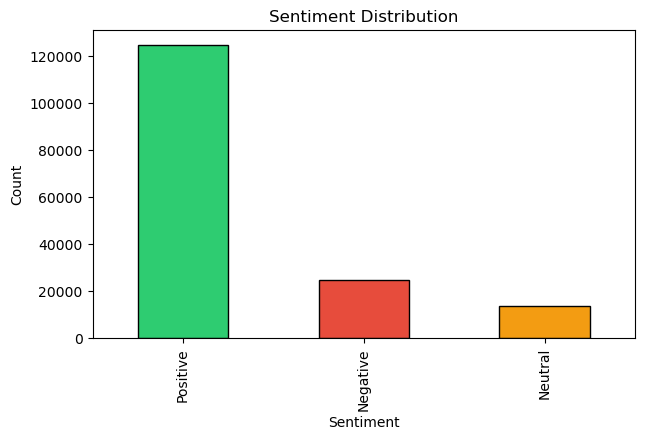

In [37]:
plt.figure(figsize=(7,4))
colors = ['#2ecc71', '#e74c3c', '#f39c12']

df['Sentiment'].value_counts().plot(
    kind='bar',
    color = colors,
    edgecolor= 'black'
)

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Review Length by Sentiment

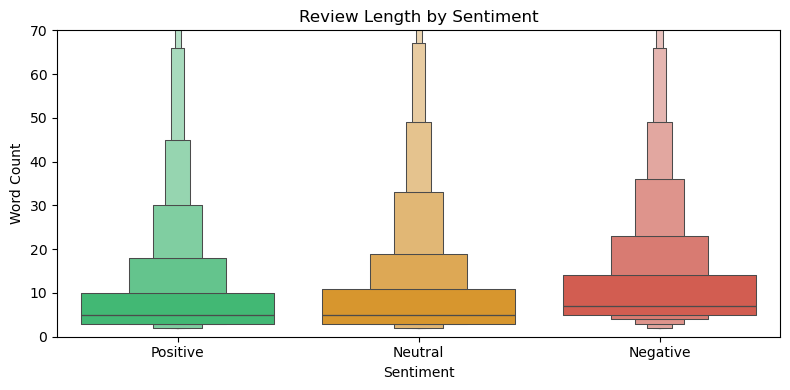

In [38]:
plt.figure(figsize=(8,4))
sns.boxenplot(
    data = df,
    x='Sentiment',
    y = 'text_length',
     palette={'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#f39c12'}
)

plt.title('Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')
plt.ylim(0,70)
plt.tight_layout()
plt.show()

#  Top Words Per Sentiment

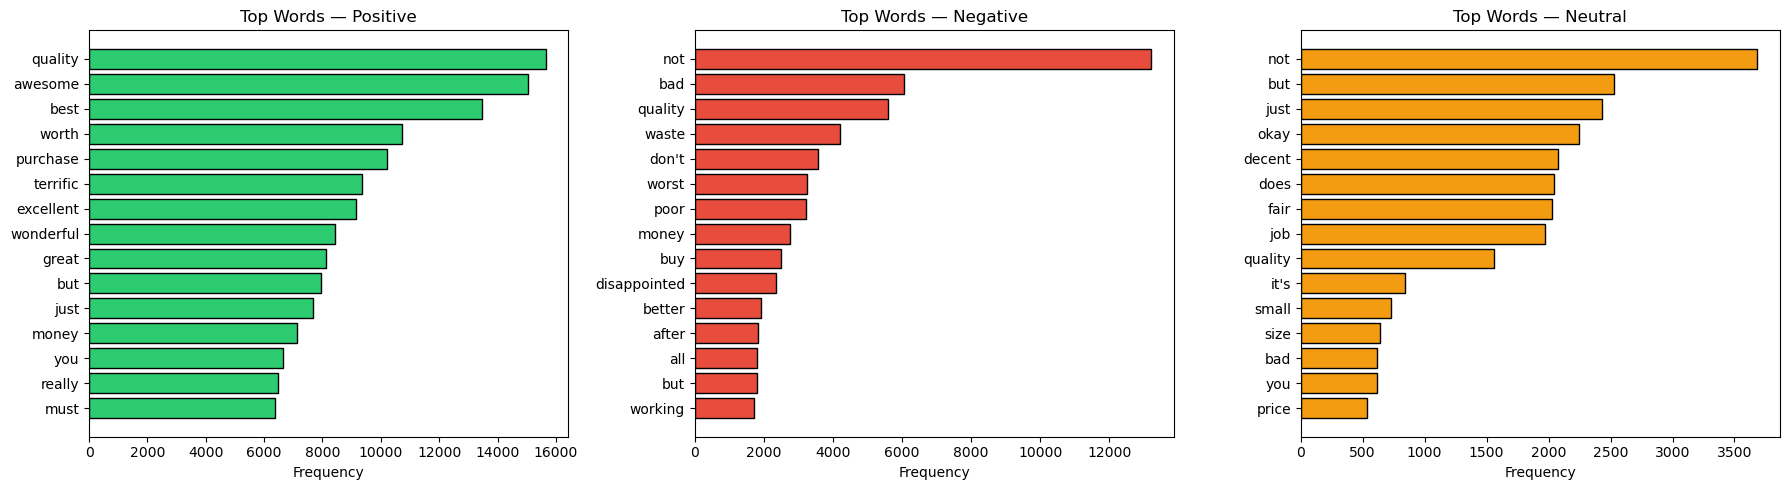

In [39]:
from collections import Counter

def get_top_words(sentiment, n=15):
    text = ' '.join(df[df['Sentiment'] == sentiment]['text'])
    words = text.lower().split()
    # Remove common stopwords manually for now
    stopwords = ['the','a','an','is','it','this','and','or','for',
                 'to','in','of','i','my','very','so','are','was',
                 'with','on','at','be','have','good','product','nice']
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiments = ['Positive', 'Negative', 'Neutral']
colors = ['#2ecc71', '#e74c3c', '#f39c12']

for ax, sentiment, color in zip(axes, sentiments, colors):
    top_words = get_top_words(sentiment)
    words, counts = zip(*top_words)
    ax.barh(words, counts, color=color, edgecolor='black')
    ax.set_title(f'Top Words — {sentiment}')
    ax.set_xlabel('Frequency')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Price vs Sentiment

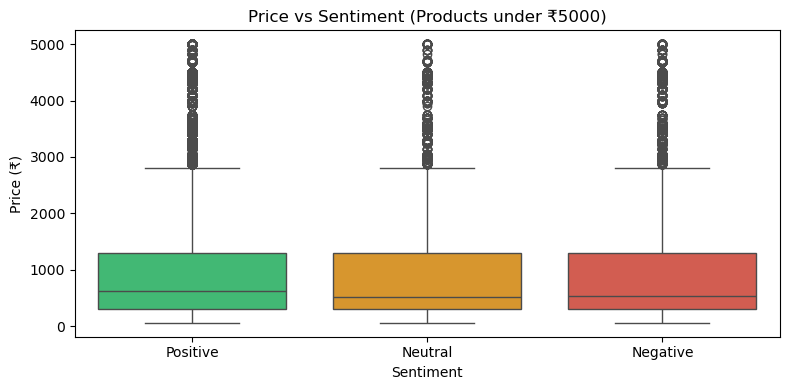

Sentiment
Negative     655.0
Neutral      648.0
Positive    1095.0
Name: Price, dtype: float64


In [40]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df[df['Price'] < 5000],  # filter outliers for visibility
    x='Sentiment',
    y='Price',
    palette={'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#f39c12'}
)
plt.title('Price vs Sentiment (Products under ₹5000)')
plt.xlabel('Sentiment')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

print(df.groupby('Sentiment')['Price'].median())

# WordCloud Positive vs Negative

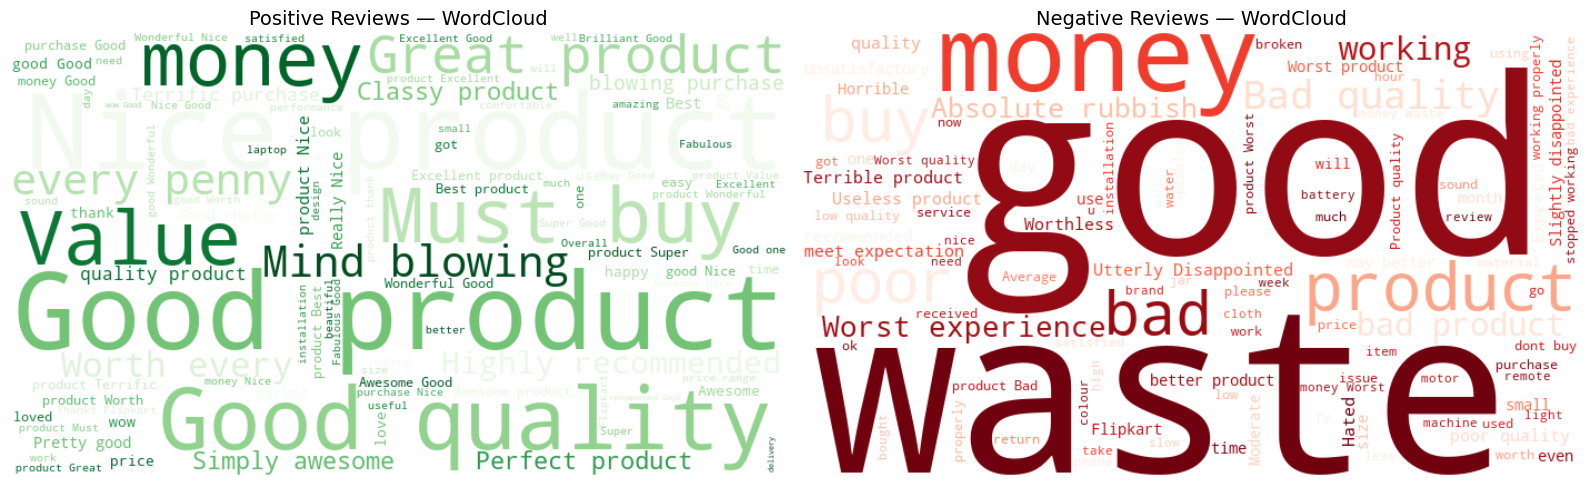

In [41]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, sentiment, color in zip(axes, ['Positive', 'Negative'], ['Greens', 'Reds']):
    text = ' '.join(df[df['Sentiment'] == sentiment]['text'])
    wc = WordCloud(
        width=700, height=400,
        background_color='white',
        colormap=color,
        max_words=100
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment} Reviews — WordCloud', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

#  Rating Distribution (actual numbers)

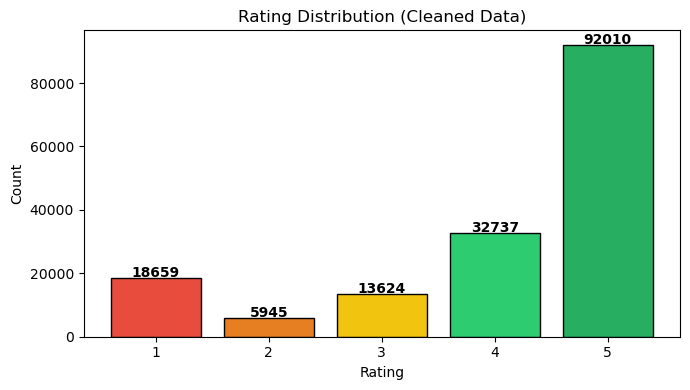

In [42]:
plt.figure(figsize=(7, 4))
rate_counts = df['Rate'].value_counts().sort_index()
bars = plt.bar(rate_counts.index, rate_counts.values,
               color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],
               edgecolor='black')
plt.title('Rating Distribution (Cleaned Data)')
plt.xlabel('Rating')
plt.ylabel('Count')
for bar, val in zip(bars, rate_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 300,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Step 5 — Text Preprocessing + TF-IDF Vectorization

### What We Do in This Step

| Task | Why |
| :--- | :--- |
| **Lowercase** | "Good" and "good" are the same word |
| **Remove punctuation** | "best!" → "best" |
| **Remove stopwords** | "is", "the", and "and" add no meaning |
| **Lemmatization** | "running" → "run", "products" → "product" |
| **TF-IDF** | Convert clean text → numbers for the model |

In [43]:
import nltk

nltk.download('stopwords') # Remove common unnecessary words
nltk.download('wordnet') # Convert words to root/base form
nltk.download('omw-1.4') # Extra support for WordNet

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mm428\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mm428\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\mm428\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [44]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re 

In [45]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Preprocessing Function

In [46]:
def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 3. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 4. Tokenize
    tokens = text.split()
    
    # 5. Remove stopwords + lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    
    return ' '.join(tokens)

In [47]:
print("Preprocessing started...")
df['text_clean'] = df['text'].apply(preprocess_text)
print("Done!")

# Compare before vs after
print("\nBefore:", df['text'][0])
print("After :", df['text_clean'][0])

Preprocessing started...
Done!

Before: Great cooler.. excellent air flow and for this price. It's so amazing and unbelievable.Just love it ?? Super!
After : great cooler excellent air flow price amazing unbelievablejust love super


In [48]:
# Remove Empty Rows After Preprocessing

In [49]:
# Some reviews may become empty after removing stopwords
df = df[df['text_clean'].str.strip() != '']
df.reset_index(drop=True, inplace=True)
print("Shape after preprocessing:", df.shape)

Shape after preprocessing: (162968, 9)


In [50]:
# Define X and y

In [51]:
X = df['text_clean']
y = df['Sentiment']

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (162968,)
y distribution:
 Sentiment
Positive    124743
Negative     24601
Neutral      13624
Name: count, dtype: int64


In [52]:
#  Train Test Split FIRST (before TF-IDF)

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserves class balance in both splits
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])
print("\nTrain sentiment distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(1))

Train size: 130374
Test size : 32594

Train sentiment distribution:
Sentiment
Positive    76.5
Negative    15.1
Neutral      8.4
Name: proportion, dtype: float64


In [54]:
# TF-IDF Vectorization

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features = 10000,
    ngram_range = (1,2),
    min_df = 5,
    max_df = 0.90
)

X_train_tfidf = tfidf .fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape :", X_test_tfidf.shape)

X_train_tfidf shape: (130374, 10000)
X_test_tfidf shape : (32594, 10000)


In [56]:
import pickle

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("TF-IDF vectorizer saved.")

TF-IDF vectorizer saved.


# Step 7 — Model Building + Evaluation

### What We Do in This Step

| Task | Detail |
| :--- | :--- |
| **Train 3 models** | Logistic Regression, Random Forest, XGBoost |
| **Evaluate each** | F1-score, Precision, Recall, Confusion Matrix |
| **Compare results** | Pick the best model |

In [57]:
# imports 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier 
from sklearn.metrics import classification_report, confusion_matrix,f1_score,ConfusionMatrixDisplay

import time

In [58]:
# Encode Labels (XGBoost needs numbers)

In [59]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}


In [60]:
#  Model 1: Logistic Regression (Baseline)

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import time

print("Training Logistic Regression...")
start = time.time()

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Train model
lr.fit(X_train_tfidf, y_train)

print(f"Done in {time.time()-start:.1f}s")


# --------------------
# Train Prediction
# --------------------
y_train_pred = lr.predict(X_train_tfidf)

print("\nTrain Classification Report:")
print(classification_report(y_train, y_train_pred))


# --------------------
# Test Prediction
# --------------------
y_test_pred = lr.predict(X_test_tfidf)

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

Training Logistic Regression...
Done in 7.8s

Train Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.96      0.96     19681
     Neutral       0.65      0.96      0.78     10899
    Positive       1.00      0.95      0.97     99794

    accuracy                           0.95    130374
   macro avg       0.87      0.95      0.90    130374
weighted avg       0.96      0.95      0.95    130374


Test Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.94      0.94      4920
     Neutral       0.62      0.90      0.73      2725
    Positive       0.99      0.94      0.97     24949

    accuracy                           0.94     32594
   macro avg       0.85      0.93      0.88     32594
weighted avg       0.95      0.94      0.94     32594



In [62]:
#  Model 2: Random Forest

In [63]:
print("Training Random Forest...")
start = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train model
rf.fit(X_train_tfidf, y_train)

print(f"Done in {time.time()-start:.1f}s")


# --------------------
# Train Prediction
# --------------------
y_train_pred_rf = rf.predict(X_train_tfidf)

print("\nTrain Random Forest Report:")
print(classification_report(y_train, y_train_pred_rf))


# --------------------
# Test Prediction
# --------------------
y_test_pred_rf = rf.predict(X_test_tfidf)

print("\nTest Random Forest Report:")
print(classification_report(y_test, y_test_pred_rf))

Training Random Forest...
Done in 454.8s

Train Random Forest Report:
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98     19681
     Neutral       0.79      0.98      0.87     10899
    Positive       1.00      0.97      0.99     99794

    accuracy                           0.97    130374
   macro avg       0.92      0.98      0.95    130374
weighted avg       0.98      0.97      0.98    130374


Test Random Forest Report:
              precision    recall  f1-score   support

    Negative       0.95      0.94      0.95      4920
     Neutral       0.72      0.82      0.77      2725
    Positive       0.98      0.97      0.97     24949

    accuracy                           0.95     32594
   macro avg       0.88      0.91      0.90     32594
weighted avg       0.95      0.95      0.95     32594



In [64]:
# Model 3: XGBoost

In [65]:
print("Training XGBoost...")
start = time.time()

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    use_label_encoder=False
)

# Train model
xgb.fit(X_train_tfidf, y_train_enc)

print(f"Done in {time.time()-start:.1f}s")


# --------------------
# Train Prediction
# --------------------
y_train_pred_xgb_enc = xgb.predict(X_train_tfidf)

# Convert encoded labels back
y_train_pred_xgb = le.inverse_transform(y_train_pred_xgb_enc)

print("\nTrain XGBoost Report:")
print(classification_report(y_train, y_train_pred_xgb))


# --------------------
# Test Prediction
# --------------------
y_test_pred_xgb_enc = xgb.predict(X_test_tfidf)

# Convert encoded labels back
y_test_pred_xgb = le.inverse_transform(y_test_pred_xgb_enc)

print("\nTest XGBoost Report:")
print(classification_report(y_test, y_test_pred_xgb))

Training XGBoost...
Done in 174.7s

Train XGBoost Report:
              precision    recall  f1-score   support

    Negative       0.98      0.93      0.95     19681
     Neutral       0.93      0.77      0.84     10899
    Positive       0.97      0.99      0.98     99794

    accuracy                           0.97    130374
   macro avg       0.96      0.90      0.92    130374
weighted avg       0.96      0.97      0.96    130374


Test XGBoost Report:
              precision    recall  f1-score   support

    Negative       0.97      0.92      0.94      4920
     Neutral       0.92      0.75      0.82      2725
    Positive       0.96      0.99      0.98     24949

    accuracy                           0.96     32594
   macro avg       0.95      0.89      0.92     32594
weighted avg       0.96      0.96      0.96     32594



In [66]:
from sklearn.metrics import accuracy_score
results = []

# Logistic Regression
results.append({
    'Model': 'Logistic Regression',
    'Train Accuracy': accuracy_score(y_train, y_train_pred),
    'Test Accuracy': accuracy_score(y_test, y_test_pred),
    'F1 Score': f1_score(y_test, y_test_pred, average='weighted')
})

# Random Forest
results.append({
    'Model': 'Random Forest',
    'Train Accuracy': accuracy_score(y_train, y_train_pred_rf),
    'Test Accuracy': accuracy_score(y_test, y_test_pred_rf),
    'F1 Score': f1_score(y_test, y_test_pred_rf, average='weighted')
})

# XGBoost
results.append({
    'Model': 'XGBoost',
    'Train Accuracy': accuracy_score(y_train, y_train_pred_xgb),
    'Test Accuracy': accuracy_score(y_test, y_test_pred_xgb),
    'F1 Score': f1_score(y_test, y_test_pred_xgb, average='weighted')
})

comparison_df = pd.DataFrame(results)

comparison_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Train Accuracy,Test Accuracy,F1 Score
2,XGBoost,0.965016,0.961956,0.960626
1,Random Forest,0.973898,0.950604,0.951730
0,Logistic Regression,0.948034,0.938302,0.942720


In [67]:
from sklearn.metrics import classification_report

print("="*50)
print("LOGISTIC REGRESSION - Detailed Report")
print("="*50)
print(classification_report(
    y_test,
    y_test_pred,
    target_names=['Negative', 'Neutral', 'Positive']
))

print("="*50)
print("RANDOM FOREST - Detailed Report")
print("="*50)
print(classification_report(
    y_test,
    y_test_pred_rf,
    target_names=['Negative', 'Neutral', 'Positive']
))

print("="*50)
print("XGBOOST - Detailed Report")
print("="*50)
print(classification_report(
    y_test,
    y_test_pred_xgb,
    target_names=['Negative', 'Neutral', 'Positive']
))

LOGISTIC REGRESSION - Detailed Report
              precision    recall  f1-score   support

    Negative       0.94      0.94      0.94      4920
     Neutral       0.62      0.90      0.73      2725
    Positive       0.99      0.94      0.97     24949

    accuracy                           0.94     32594
   macro avg       0.85      0.93      0.88     32594
weighted avg       0.95      0.94      0.94     32594

RANDOM FOREST - Detailed Report
              precision    recall  f1-score   support

    Negative       0.95      0.94      0.95      4920
     Neutral       0.72      0.82      0.77      2725
    Positive       0.98      0.97      0.97     24949

    accuracy                           0.95     32594
   macro avg       0.88      0.91      0.90     32594
weighted avg       0.95      0.95      0.95     32594

XGBOOST - Detailed Report
              precision    recall  f1-score   support

    Negative       0.97      0.92      0.94      4920
     Neutral       0.92      0.75

In [68]:
import pickle

# Save XGBoost model
with open('best_model_xgb.pkl', 'wb') as f:
    pickle.dump(xgb, f)

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("All 3 saved: model + encoder + vectorizer")

All 3 saved: model + encoder + vectorizer


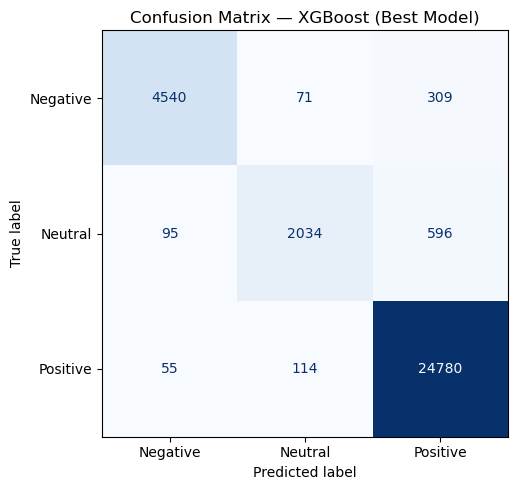

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(
    y_test,
    y_test_pred_xgb,
    labels=['Negative', 'Neutral', 'Positive']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Neutral', 'Positive']
)

disp.plot(ax=ax, cmap='Blues', colorbar=False)

plt.title('Confusion Matrix — XGBoost (Best Model)')
plt.tight_layout()
plt.show()

In [70]:
# Transform full cleaned data
X_all_tfidf = tfidf.transform(df['text_clean'])

# Predict using XGBoost
y_all_enc = xgb.predict(X_all_tfidf)
df['Predicted_Sentiment'] = le.inverse_transform(y_all_enc)

print("Predictions added!")
print(df['Predicted_Sentiment'].value_counts())

Predictions added!
Predicted_Sentiment
Positive    128390
Negative     23411
Neutral      11167
Name: count, dtype: int64


In [71]:
# First 2-3 words of product name = rough category
df['Category'] = df['ProductName'].apply(
    lambda x: ' '.join(str(x).split()[:2])
)

print("Sample categories:")
print(df['Category'].value_counts().head(20))

Sample categories:
Category
cello Pack            7073
MILTON Thermosteel    5941
Home Sizzler          3562
Flipkart SmartBuy     2479
MarQ by               2339
Kadio Analog          2303
Mi 5A                 2154
Butterfly Rapid       2057
CMerchants Multi      2049
Cosito 144            1984
LA VERNE              1961
Google Nest           1856
Singer FM             1835
Pigeon Favourite      1745
Canon EOS             1734
NIVIA Storm           1672
POCO C31              1633
Mi 3i                 1612
SportSoul Cotton      1543
SAMSUNG 253           1508
Name: count, dtype: int64


Negative sentiment % by price range:
Price_Range
<500      16.2
500-1K    15.3
1K-2K     13.1
2K-5K     17.1
5K+       10.2
Name: Negative_%, dtype: float64


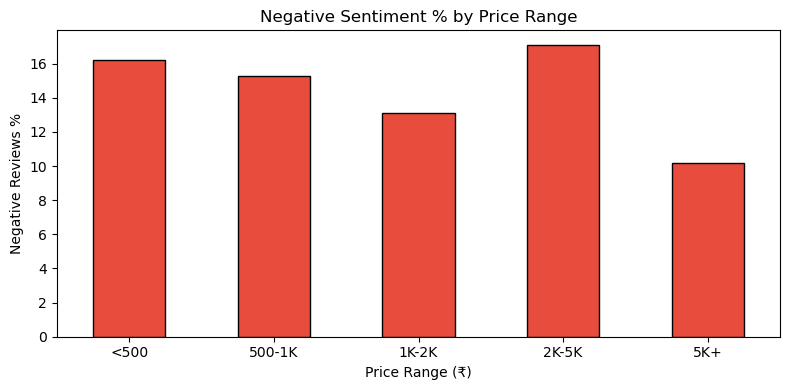

In [72]:
# Create price buckets
bins   = [0, 500, 1000, 2000, 5000, 100000]
labels = ['<500', '500-1K', '1K-2K', '2K-5K', '5K+']

df['Price_Range'] = pd.cut(df['Price'], bins=bins, labels=labels)

# Negative % per price range
price_sentiment = df.groupby(['Price_Range', 'Predicted_Sentiment']).size().unstack(fill_value=0)
price_sentiment['Negative_%'] = (
    price_sentiment['Negative'] / price_sentiment.sum(axis=1) * 100
).round(1)

print("Negative sentiment % by price range:")
print(price_sentiment['Negative_%'])

# Plot
plt.figure(figsize=(8, 4))
price_sentiment['Negative_%'].plot(
    kind='bar',
    color='#e74c3c',
    edgecolor='black'
)
plt.title('Negative Sentiment % by Price Range')
plt.xlabel('Price Range (₹)')
plt.ylabel('Negative Reviews %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

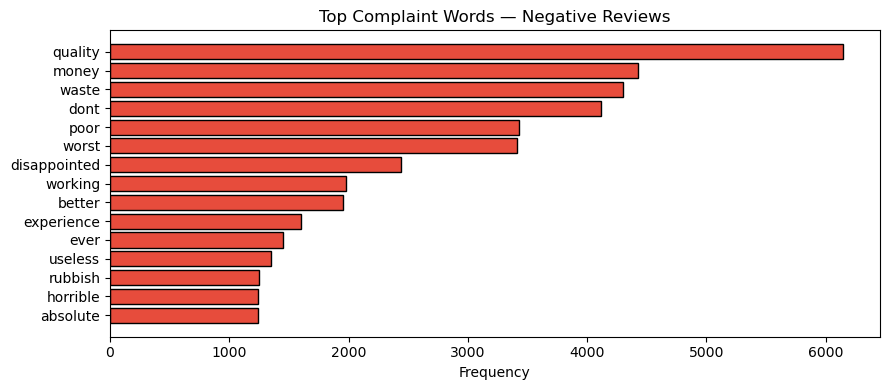


Top 15 complaint words:
  quality              6148
  money                4424
  waste                4297
  dont                 4117
  poor                 3429
  worst                3412
  disappointed         2437
  working              1982
  better               1952
  experience           1601
  ever                 1447
  useless              1347
  rubbish              1253
  horrible             1244
  absolute             1237


In [73]:
from collections import Counter

# Get all negative review text
negative_text = ' '.join(df[df['Predicted_Sentiment'] == 'Negative']['text_clean'])
words = negative_text.split()

# Remove generic words
ignore = ['product', 'good', 'nice', 'buy', 'get', 'one', 
          'use', 'would', 'also', 'item', 'got', 'like']
words = [w for w in words if w not in ignore and len(w) > 3]

top_complaints = Counter(words).most_common(15)
words_list, counts = zip(*top_complaints)

plt.figure(figsize=(9, 4))
plt.barh(words_list, counts, color='#e74c3c', edgecolor='black')
plt.title('Top Complaint Words — Negative Reviews')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 15 complaint words:")
for word, count in top_complaints:
    print(f"  {word:<20} {count}")

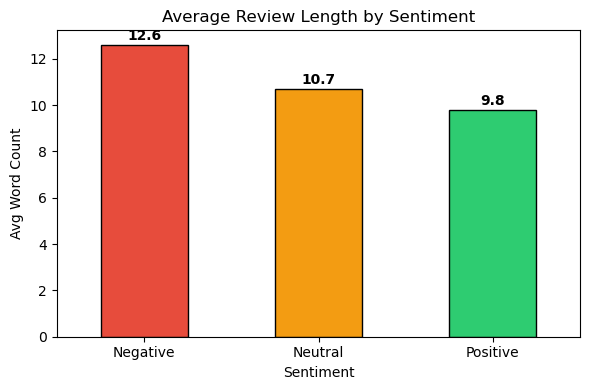

In [74]:
avg_length = df.groupby('Predicted_Sentiment')['text_length'].mean().round(1)

plt.figure(figsize=(6, 4))
colors = ['#e74c3c', '#f39c12', '#2ecc71']
avg_length.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Average Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Avg Word Count')
plt.xticks(rotation=0)
for i, v in enumerate(avg_length):
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [75]:
print("="*55)
print("        BUSINESS INSIGHTS SUMMARY")
print("="*55)

total       = len(df)
neg_count   = (df['Predicted_Sentiment'] == 'Negative').sum()
pos_count   = (df['Predicted_Sentiment'] == 'Positive').sum()
neg_pct     = round(neg_count / total * 100, 1)

print(f"""
DATASET OVERVIEW
  Total Reviews Analyzed : {total:,}
  Positive Reviews       : {pos_count:,}
  Negative Reviews       : {neg_count:,} ({neg_pct}%)

KEY FINDINGS
  1. {neg_pct}% of all reviews are Negative
     → 1 in every {round(100/neg_pct)} customers is dissatisfied

""" )

        BUSINESS INSIGHTS SUMMARY

DATASET OVERVIEW
  Total Reviews Analyzed : 162,968
  Positive Reviews       : 128,390
  Negative Reviews       : 23,411 (14.4%)

KEY FINDINGS
  1. 14.4% of all reviews are Negative
     → 1 in every 7 customers is dissatisfied




In [76]:
# Test with your own sample reviews
new_reviews = [
    "Worst product ever, complete waste of money, stopped working in 2 days",
    "Amazing quality, fast delivery, highly recommend to everyone",
    "Average product, nothing special, works okay for the price"
]

# Preprocess
new_clean = [preprocess_text(r) for r in new_reviews]

# Vectorize
new_tfidf = tfidf.transform(new_clean)

# Predict
new_pred_enc = xgb.predict(new_tfidf)
new_pred = le.inverse_transform(new_pred_enc)

print("Live Predictions:")
print("-"*55)
for review, sentiment in zip(new_reviews, new_pred):
    print(f"Review    : {review[:50]}...")
    print(f"Predicted : {sentiment}")
    print("-"*55)

Live Predictions:
-------------------------------------------------------
Review    : Worst product ever, complete waste of money, stopp...
Predicted : Negative
-------------------------------------------------------
Review    : Amazing quality, fast delivery, highly recommend t...
Predicted : Positive
-------------------------------------------------------
Review    : Average product, nothing special, works okay for t...
Predicted : Neutral
-------------------------------------------------------


# Business Insights — What We Found from Customer Reviews

---

## 1. Product Quality is the Biggest Problem

### What we found

Customers used these words many times:

```text
quality      6,148
poor         3,429
worst        3,412
bad          many times
```

### What this means

Many customers are unhappy with **product quality**.

Products are not meeting customer expectations.

### What company should do

* Check product quality before shipping
* Check sellers with too many bad reviews
* Give trusted sellers a quality badge

---

## 2. Customers Feel They Wasted Money

### What we found

Customers often used:

```text
money    4,424
waste    4,297
```

Example reviews:

```text
"waste of money"
"not worth the price"
```

### What this means

Customers feel:

> Product quality is not worth the money they paid.

### What company should do

* Improve product descriptions
* Show honest customer reviews clearly
* Remove misleading product information

---

## 3. ₹2K–₹5K Products Have More Complaints

### What we found

Negative review rate:

```text
Below ₹500     → 16.2%
₹500–1K        → 15.3%
₹1K–2K         → 13.1%
₹2K–5K         → 17.1%  ← Highest
₹5K+           → 10.2%
```

### What this means

Customers buying products between **₹2,000 to ₹5,000** are more disappointed.

### What company should do

* Check quality in this price range
* Improve return policy
* Show warranty details clearly

---

## 4. Unhappy Customers Write Longer Reviews

### What we found

Average review length:

```text
Negative review → 12.6 words
Neutral review  → 10.7 words
Positive review → 9.8 words
```

### What this means

Unhappy customers explain problems in detail.

This gives useful feedback.

### What company should do

* Read long negative reviews carefully
* Find common customer problems
* Use feedback to improve products

---

## 5. Product Reliability Problem

### What we found

Words used often:

```text
working     1,982
useless     1,347
```

Example reviews:

```text
"stopped working"
"not working"
```

### What this means

Some products stop working after delivery.

### What company should do

* Check products with many complaints
* Remove poor-quality sellers
* Give better replacement support

---

# Final Summary

```text
1. Product quality is the biggest problem.

2. Many customers feel products are not worth the money.

3. ₹2K–₹5K products have the most complaints.

4. Negative reviews give useful feedback.

5. Some products stop working after purchase.
```

## Recommendations

* Improve quality checks
* Monitor bad sellers
* Focus on ₹2K–₹5K products
* Use review analysis to improve products


In [80]:
df_dashboard = df[['ProductName', 'Price', 'Rate', 
                    'text', 'text_length', 'Sentiment',
                    'Predicted_Sentiment', 'Price_Range']].copy()

df_dashboard.to_csv(r'C:\Users\mm428\Downloads\Duck_db_project.csv', index=False)